In [27]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

## EDA: 2015-17 MBTA Systemwide Access Time by Access Mode

Below we have a quick look for census data. It is already processed so not much data cleaning are made. The original data is a `.xlsx` spreadsheet where multiple sheets are put together, so we just "cleaned" it by rearranging them manually. 

In [ ]:
surveyAccessTimeByMode2017 = pd.read_excel('../MBTA SYSTEMWIDE PASSENGER SURVEY 2015-17/MBTA systemwide survey access time by access mode_cleaned.xlsx')
surveyAccessTimeByMode2017.head()

,MBTA Mode,Access Time,Walked or bicycled,Drove alone,Carpooled,Dropped off by personal vehicle,Dropped off by other vehicle
0,Bus,0-5 minutes,122456.415725,721.094653,52.807582,692.695693,520.609707
1,Bus,6-10 minutes,40328.820462,621.170022,67.202845,456.212539,756.460537
2,Bus,11-15 minutes,11368.791206,308.991252,13.108435,213.855123,502.517205
3,Bus,16-20 minutes,3872.066355,169.663578,7.726715,142.737507,407.454906
4,Bus,21-30 minutes,2121.060105,219.827075,5.863057,191.355921,406.556139


In [29]:
# surveyResultByMode.round()
surveyAccessTimeByMode2017.groupby('MBTA Mode').sum().drop('Access Time', axis=1).round()

,Walked or bicycled,Drove alone,Carpooled,Dropped off by personal vehicle,Dropped off by other vehicle
MBTA Mode,,,,,
Bus,181133.0,2101.0,161.0,1820.0,2886.0
Commuter Rail,48739.0,29115.0,2130.0,8903.0,3455.0
Ferry,1843.0,1424.0,128.0,114.0,67.0
Rail Rapid Transit,321685.0,16451.0,2873.0,8838.0,14694.0
Silver Line,16166.0,205.0,73.0,132.0,347.0


In [30]:
modeDist = surveyAccessTimeByMode2017.groupby('MBTA Mode').sum().drop('Access Time', axis=1).applymap(math.log)
modeDist = modeDist.add_suffix('_log')
modeDist

/var/folders/ct/74xdkj1d0zb2p573f6j7h2gc0000gn/T/ipykernel_79959/4022511579.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  modeDist = surveyAccessTimeByMode2017.groupby('MBTA Mode').sum().drop('Access Time', axis=1).applymap(math.log)


,Walked or bicycled_log,Drove alone_log,Carpooled_log,Dropped off by personal vehicle_log,Dropped off by other vehicle_log
MBTA Mode,,,,,
Bus,12.106988,7.650320,5.080650,7.506734,7.967727
Commuter Rail,10.794231,10.279017,7.664101,9.094118,8.147654
Ferry,7.518916,7.261464,4.854513,4.736297,4.197486
Rail Rapid Transit,12.681327,9.708118,7.962962,9.086868,9.595222
Silver Line,9.690672,5.324440,4.288450,4.886021,5.849131


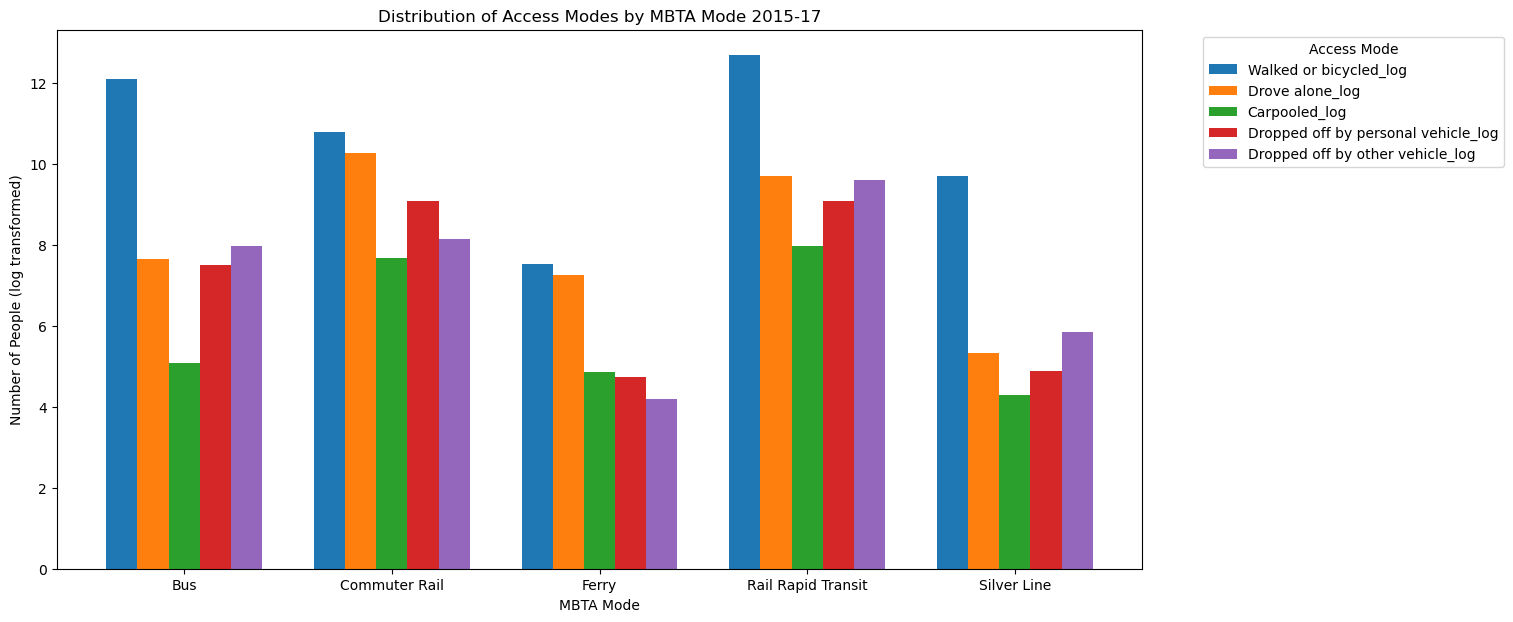

In [ ]:
mbta_modes = modeDist.index
access_modes = modeDist.columns

x = np.arange(len(mbta_modes))
width = 0.15  # Width of each bar

fig, ax = plt.subplots(figsize=(14, 7))

for i, access_mode in enumerate(access_modes):
    ax.bar(x + i * width, modeDist[access_mode], width, label=access_mode)

ax.set_xlabel('MBTA Mode')
ax.set_ylabel('Number of People (log transformed)')
ax.set_title('Distribution of Access Modes by MBTA Mode 2015-17')
ax.set_xticks(x + width * (len(access_modes) - 1) / 2)
ax.set_xticklabels(mbta_modes)
ax.legend(title='Access Mode', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## Whole Census Survery Result Data Import

### 2023 (New) Data

In [ ]:
surveyResult2023 = pd.read_csv('../MBTA SYSTEMWIDE PASSENGER SURVEY 2023/MBTA_2023_System-Wide_Passenger_Survey_Data.csv')
print(surveyResult2023.shape)
print(surveyResult2023['aggregation_level'].unique())
print(surveyResult2023['measure_group'].unique())
surveyResult2023.head()

(13374, 8)
['Reporting Group' 'Rapid Transit or Bus Rapid Transit Line'
 'Service Mode' 'Systemwide']
['Income' 'Other Demographics' 'Race and Ethnicity'
 'Trip Purpose and Frequency' 'Vehicles' 'Access Mode' 'Alternative Modes'
 'Fares']


,aggregation_level,service_mode,reporting_group,measure_group,measure,category,weighted_percent,ObjectId
0,Reporting Group,Bus,104,Income,Household Income,60% to 80% of Area Median Income,0.208875,1
1,Reporting Group,Bus,104,Income,Household Income,80% to 100% of Area Median Income,0.083513,2
2,Reporting Group,Bus,104,Income,Household Income,100% to 140% of Area Median Income,0.043782,3
3,Reporting Group,Bus,104,Income,Household Income,Prefer not to say,0.061199,4
4,Reporting Group,Bus,104,Income,Title VI Low-Income,Yes,0.864406,5


### 2015-17 (Old) Data

In [ ]:
surveyResultByMode2017_station = pd.read_excel(
    '../MBTA SYSTEMWIDE PASSENGER SURVEY 2015-17/MBTA systemwide survey results by station and line 2015-17.xlsx', sheet_name=0)

print(surveyResultByMode2017_station.shape)
surveyResultByMode2017_station.head()

(225, 115)


,Mode,Line,Station,Trip purpose: Home-based work,Trip purpose: Home-based school,Trip purpose: Home-based social activity,Trip purpose: Home-based other,Trip purpose: Non-home-based,Count: Trip purpose,Trip frequency: 6-7 days a week,...,Gender: Woman,Gender: Other,Gender: Prefer not to say,Count: Gender,Ability to understand English: Always,Ability to understand English: Often,Ability to understand English: Sometimes,Ability to understand English: Never,Ability to understand English: Prefer not to say,Count: Ability to understand English
0,Commuter Rail,Fairmount and Franklin Lines,Readville,400.0,19.0,0.0,13.0,6.0,68.0,39.0,...,316.0,0.0,0.0,71.0,458.0,0.0,0.0,0.0,0.0,71.0
1,Commuter Rail,Fairmount Line,Newmarket to Morton Street,630.0,62.0,41.0,31.0,31.0,77.0,124.0,...,547.0,0.0,21.0,82.0,847.0,0.0,0.0,0.0,0.0,82.0
2,Commuter Rail,Fairmount Line,South Station,689.0,24.0,24.0,20.0,20.0,193.0,77.0,...,492.0,0.0,12.0,201.0,806.0,4.0,0.0,0.0,8.0,203.0
3,Commuter Rail,"Fairmount, Franklin, and Providence/Stoughton ...",Hyde Park and Fairmount,906.0,41.0,21.0,21.0,48.0,150.0,28.0,...,595.0,0.0,7.0,152.0,1058.0,7.0,0.0,0.0,7.0,155.0
4,Commuter Rail,Fitchburg Line,Brandeis/Roberts,427.0,65.0,14.0,7.0,28.0,75.0,14.0,...,355.0,0.0,22.0,79.0,565.0,0.0,0.0,0.0,7.0,79.0


In [ ]:
surveyResultByMode2017_line = pd.read_excel(
    '../MBTA SYSTEMWIDE PASSENGER SURVEY 2015-17/MBTA systemwide survey results by station and line 2015-17.xlsx', sheet_name=2)

print(surveyResultByMode2017_line.shape)
surveyResultByMode2017_line.head()

(159, 114)


,Mode,Line,Trip purpose: Home-based work,Trip purpose: Home-based school,Trip purpose: Home-based social activity,Trip purpose: Home-based other,Trip purpose: Non-home-based,Count: Trip purpose,Trip frequency: 6-7 days a week,Trip frequency: 5 days a week,...,Gender: Woman,Gender: Other,Gender: Prefer not to say,Count: Gender,Ability to understand English: Always,Ability to understand English: Often,Ability to understand English: Sometimes,Ability to understand English: Never,Ability to understand English: Prefer not to say,Count: Ability to understand English
0,Bus,1,7093.0,1035.0,725.0,958.0,1113.0,844,1605.0,5126.0,...,7015.0,26.0,207.0,856,10691.0,181.0,104.0,26.0,78.0,856
1,Bus,4,311.0,3.0,3.0,9.0,16.0,212,10.0,272.0,...,250.0,0.0,13.0,228,360.0,6.0,3.0,0.0,0.0,228
2,Bus,7,3769.0,37.0,37.0,161.0,75.0,654,312.0,3045.0,...,2571.0,0.0,50.0,658,4043.0,25.0,0.0,12.0,12.0,656
3,Bus,8,1906.0,251.0,63.0,314.0,231.0,264,377.0,1801.0,...,2178.0,0.0,21.0,282,2744.0,105.0,84.0,0.0,21.0,282
4,Bus,9,4120.0,117.0,408.0,525.0,78.0,540,428.0,3109.0,...,3692.0,0.0,19.0,548,5188.0,78.0,19.0,0.0,39.0,548


## Trip Purpose Comparison

In [35]:
tripPurposeByLine2017 = surveyResultByMode2017_line.loc[:, surveyResultByMode2017_line.columns.str.contains('Mode|Line|Trip purpose', case=True)]
tripPurposeByLine2023 = surveyResult2023[surveyResult2023['measure'] == 'Trip Purpose']
tripPurposeByStation2017 = surveyResultByMode2017_station.loc[:, surveyResultByMode2017_station.columns.str.contains('Mode|Line|Station|Trip purpose', case=True)]
# tripPurposeByStation2023 = surveyResult2023.loc[:, surveyResultByMode2023_station.columns.str.contains('Mode|Line|Station|Trip purpose', case=True)]

In [36]:
tripPurposeByLine2023['service_mode'].unique()

array(['Bus', 'Commuter Rail',
       'Rapid Transit or Bus Rapid Transit - Blue Line', 'Ferry',
       'Rapid Transit or Bus Rapid Transit - Green Line',
       'Rapid Transit or Bus Rapid Transit - Mattapan Trolley',
       'Rapid Transit or Bus Rapid Transit - Orange Line',
       'Rapid Transit or Bus Rapid Transit - Red Line',
       'Rapid Transit or Bus Rapid Transit - Silver Line BRT',
       'All Modes', 'Rapid Transit or Bus Rapid Transit'], dtype=object)

### Trip Purpose 2017

In [37]:
tripPurposeByMode2017 = tripPurposeByLine2017.groupby('Mode').sum(numeric_only=True).iloc[:, :-2]

tripPurposeByMode2017_log = np.log(tripPurposeByMode2017 + 1)
tripPurposeByMode2017_log.columns = tripPurposeByMode2017_log.columns.str.replace("Trip purpose: ", "", regex=False)
tripPurposeByMode2017_log

,Home-based work,Home-based school,Home-based social activity,Home-based other,Non-home-based
Mode,,,,,
Bus,12.304664,10.161187,9.473089,10.548048,9.838416
Commuter Rail,11.602784,7.925519,7.458763,8.133587,8.257645
Ferry,8.174703,0.000000,4.060443,4.060443,4.454347
Rail Rapid Transit,13.138640,10.600975,10.601000,11.081635,10.932553
Silver Line,9.938275,6.781058,6.709304,8.654169,7.922261


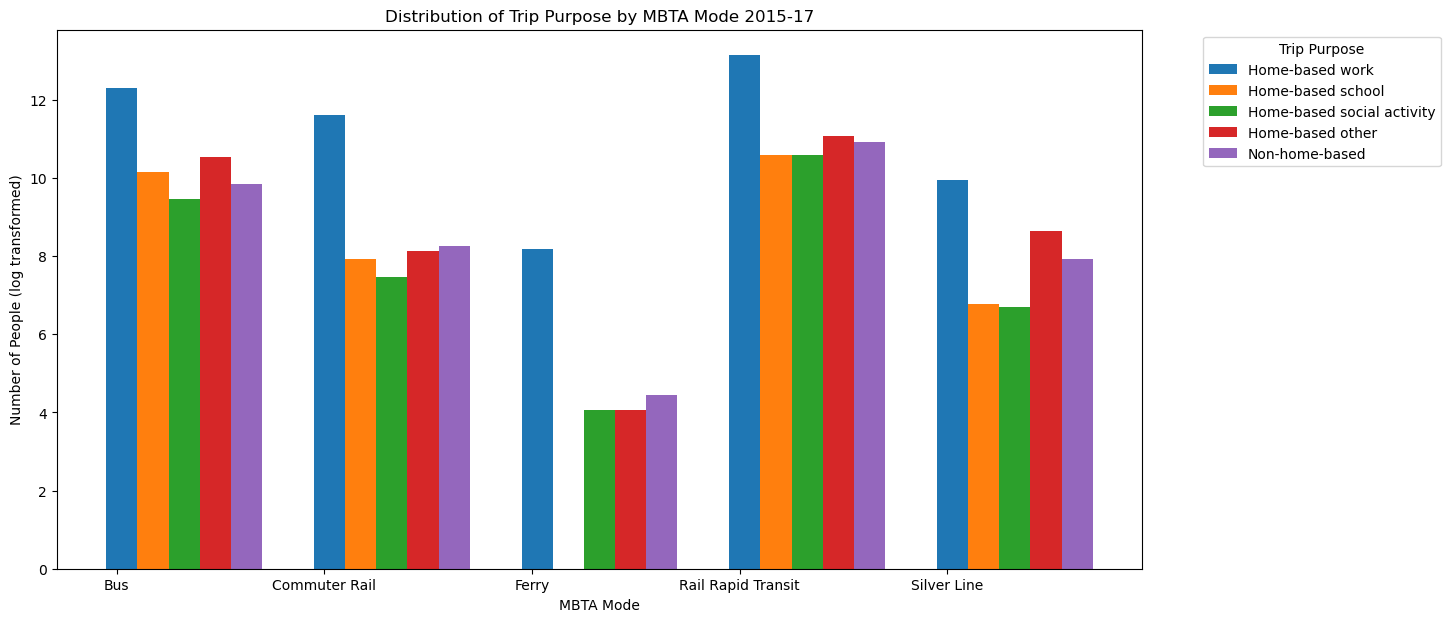

In [38]:
# Prepare data
mbta_modes = tripPurposeByMode2017_log.index
tripPurpose = tripPurposeByMode2017_log.columns

# Define the positions for each MBTA mode on the x-axis
x = np.arange(len(mbta_modes))
width = 0.15  # Width of each bar

# Create a figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each access mode as a separate set of bars
for i, tripPurpose in enumerate(tripPurpose):
    ax.bar(x + i * width, tripPurposeByMode2017_log[tripPurpose], width, label=tripPurpose)

# Set labels and title
ax.set_xlabel('MBTA Mode')
ax.set_ylabel('Number of People (log transformed)')
ax.set_title('Distribution of Trip Purpose by MBTA Mode 2015-17')
ax.set_xticks(x + width * (len(tripPurpose) - 1) / 2 - 1)
ax.set_xticklabels(mbta_modes)
ax.legend(title='Trip Purpose', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [39]:
tripPurposeByMode2017 = tripPurposeByLine2017.groupby('Mode').sum(numeric_only=True).iloc[:, :-2]

sum_row = tripPurposeByMode2017.sum()
tripPurposeByMode2017.loc['TOTAL'] = sum_row

tripPurposeByMode2017

,Trip purpose: Home-based work,Trip purpose: Home-based school,Trip purpose: Home-based social activity,Trip purpose: Home-based other,Trip purpose: Non-home-based
Mode,,,,,
Bus,220722.0,25878.0,13004.0,38102.0,18739.0
Commuter Rail,109401.0,2766.0,1734.0,3406.0,3856.0
Ferry,3549.0,0.0,57.0,57.0,85.0
Rail Rapid Transit,508204.0,40173.0,40174.0,64966.0,55968.0
Silver Line,20707.0,880.0,819.0,5733.0,2757.0
TOTAL,862583.0,69697.0,55788.0,112264.0,81405.0


In [40]:
# home-based work
tripPurposeByMode2017_per = tripPurposeByMode2017.div(tripPurposeByMode2017.sum(axis=1), axis=0)
tripPurposeByMode2017_per.columns = tripPurposeByMode2017_per.columns.str.replace("Trip purpose: ", "", regex=False)
tripPurposeByMode2017_per

,Home-based work,Home-based school,Home-based social activity,Home-based other,Non-home-based
Mode,,,,,
Bus,0.697505,0.081777,0.041094,0.120406,0.059217
Commuter Rail,0.902924,0.022829,0.014311,0.028111,0.031825
Ferry,0.946905,0.000000,0.015208,0.015208,0.022679
Rail Rapid Transit,0.716300,0.056623,0.056624,0.091568,0.078885
Silver Line,0.670216,0.028483,0.026508,0.185558,0.089235
TOTAL,0.729928,0.058978,0.047208,0.094999,0.068886


/var/folders/ct/74xdkj1d0zb2p573f6j7h2gc0000gn/T/ipykernel_79959/1333643132.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels=np.round(np.arange(0, 1, 0.2), decimals=1), fontsize=15)


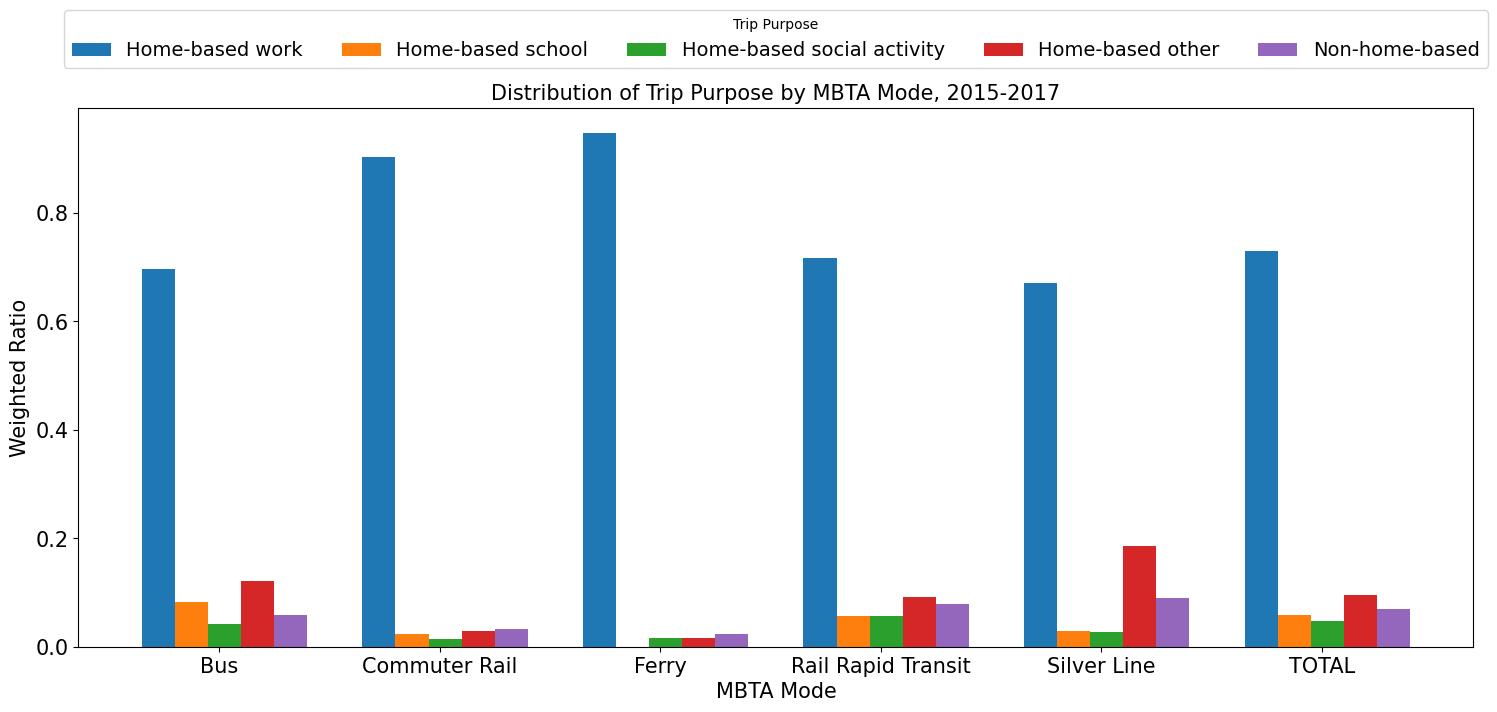

In [41]:
# Prepare data
mbta_modes = tripPurposeByMode2017_per.index
tripPurpose = tripPurposeByMode2017_per.columns

# Define the positions for each MBTA mode on the x-axis
x = np.arange(len(mbta_modes))
width = 0.15  # Width of each bar

# Create a figure and axis
fig, ax = plt.subplots(figsize=(18, 7))

# Plot each access mode as a separate set of bars
for i, tripPurpose in enumerate(tripPurpose):
    ax.bar(x + i * width, tripPurposeByMode2017_per[tripPurpose], width, label=tripPurpose)

# Set labels and title
ax.set_xlabel('MBTA Mode', fontsize=15)
ax.set_ylabel('Weighted Ratio', fontsize=15)
ax.set_title('Distribution of Trip Purpose by MBTA Mode, 2015-2017', fontsize=15)
ax.set_xticks(x + width * (len(tripPurpose) - 1) / 2 - 0.7)
ax.set_xticklabels(mbta_modes, fontsize=15)
ax.set_yticklabels(labels=np.round(np.arange(0, 1, 0.2), decimals=1), fontsize=15)

ax.legend(
    title='Trip Purpose',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),  # Move to the center above the chart
    ncol=len(tripPurpose),       # Arrange legend in one row
    fontsize=14
)

# plt.tight_layout()
plt.show()

### Trip Purpose 2023

In [42]:
tripPurposeByLine2023 = surveyResult2023[surveyResult2023['measure'] == 'Trip Purpose']

# tripPurposeByLine2023 = tripPurposeByLine2023.loc[:, ]
tripPurposeByLine2023_serviceMode = tripPurposeByLine2023[tripPurposeByLine2023['aggregation_level'] == 'Service Mode']
tripPurposeByLine2023_serviceMode = tripPurposeByLine2023_serviceMode.loc[:, tripPurposeByLine2023_serviceMode.columns.str.contains("service_mode|category|weighted_percent")]

tripPurposeByLine2023_serviceMode

,service_mode,category,weighted_percent
12802,Bus,Home-based Work,0.549140
12803,Bus,Home-based School,0.093090
12804,Bus,Home-based Social Activity,0.084454
12805,Bus,Home-based Other,0.185989
12806,Bus,Non-home Based,0.087327
13105,Commuter Rail,Home-based Work,0.499472
13107,Commuter Rail,Home-based School,0.106929
13127,Ferry,Home-based Work,0.591856
13129,Ferry,Home-based School,0.015010
13131,Ferry,Home-based Social Activity,0.170585


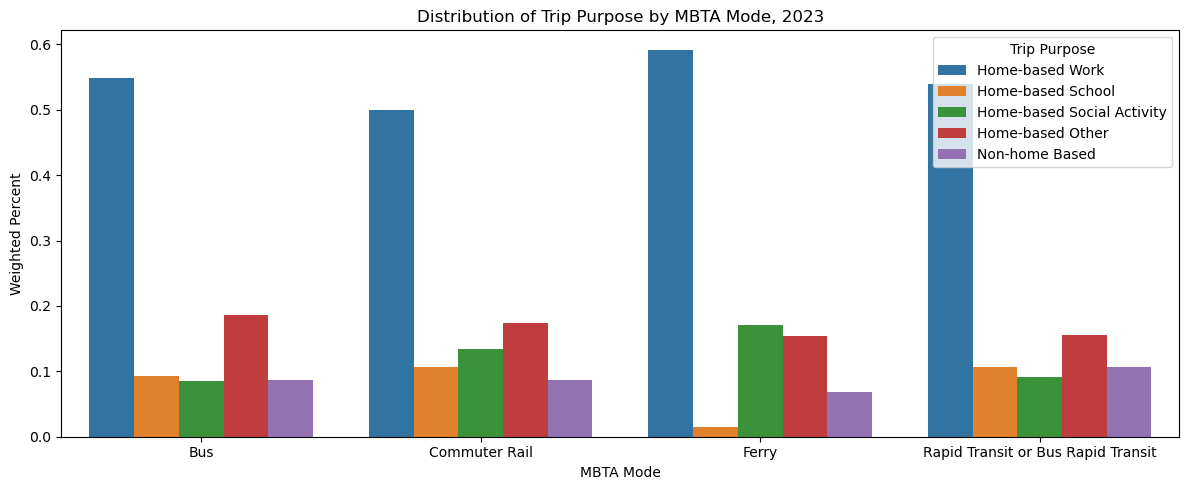

In [43]:
# Set figure size
plt.figure(figsize=(12, 5))

# Plot a bar chart using seaborn
sns.barplot(data=tripPurposeByLine2023_serviceMode, x='service_mode', y='weighted_percent', hue='category')

# Set labels and title
plt.xlabel('MBTA Mode')
plt.ylabel('Weighted Percent')
plt.title('Distribution of Trip Purpose by MBTA Mode, 2023')
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(title='Trip Purpose', loc='upper right')
plt.show()

In [44]:
# tripPurposeByLine2023 = surveyResult2023[surveyResult2023['measure'] == 'Trip Purpose']

# tripPurposeByLine2023_ReportingGroup = tripPurposeByLine2023[tripPurposeByLine2023['aggregation_level'] == 'Reporting Group']

# tripPurposeByLine2023_ReportingGroup

## Trip Access Mode Comparison

In [45]:
accessMode2023 = surveyResult2023[surveyResult2023['measure_group'] == 'Access Mode']
accessMode2023 = accessMode2023.drop(columns=['measure', 'ObjectId'])
accessMode2023ByLine = accessMode2023[accessMode2023['aggregation_level'] == 'Rapid Transit or Bus Rapid Transit Line']
accessMode2023ByLine = accessMode2023ByLine.drop(columns=['aggregation_level', 'service_mode', 'measure_group']).reset_index(drop=True)
accessMode2023ByLine

,reporting_group,category,weighted_percent
0,All Blue Line,Walked,0.843072
1,All Blue Line,Carpooled or Dropped off by Personal Vehicle,0.047245
2,All Blue Line,Drove Alone,0.011214
3,All Blue Line,Private Shuttle or Other Transit,0.053385
4,All Blue Line,Taxi or Rideshare Company,0.023084
5,All Blue Line,"Bike, Scooter or Other Micromobility",0.017696
6,All Blue Line,The RIDE,0.004303
7,All Green Line,Walked,0.895992
8,All Green Line,Carpooled or Dropped off by Personal Vehicle,0.034007
9,All Green Line,Drove Alone,0.016522


In [46]:
accessMode2023['aggregation_level'].unique()

array(['Reporting Group', 'Rapid Transit or Bus Rapid Transit Line',
       'Service Mode', 'Systemwide'], dtype=object)

In [47]:
accessMode2023ByMode = accessMode2023[accessMode2023['aggregation_level'] == 'Service Mode']
accessMode2023ByMode = accessMode2023ByMode.drop(columns=['aggregation_level', 'reporting_group', 'measure_group']).reset_index(drop=True)
accessMode2023ByMode

,service_mode,category,weighted_percent
0,Commuter Rail,Walked,0.612344
1,Commuter Rail,Carpooled or Dropped off by Personal Vehicle,0.150750
2,Commuter Rail,Drove Alone,0.084691
3,Commuter Rail,Private Shuttle or Other Transit,0.030045
4,Commuter Rail,Taxi or Rideshare Company,0.075993
5,Commuter Rail,"Bike, Scooter or Other Micromobility",0.037864
6,Commuter Rail,The RIDE,0.008314
7,Ferry,Walked,0.688334
8,Ferry,Carpooled or Dropped off by Personal Vehicle,0.132834
9,Ferry,Drove Alone,0.103268


In [48]:
# combine 'Walked' and 'Bike, Scooter or Other Micromobility'
walk_bike = accessMode2023ByMode[accessMode2023ByMode['category'].isin(['Walked', 'Bike, Scooter or Other Micromobility'])]
combined_walkbike = walk_bike.groupby('service_mode', as_index=False)['weighted_percent'].agg({
    'weighted_percent': 'sum'
})
combined_walkbike['category'] = 'Walked + Bike/Scooter/Micromobility'
accessMode2023ByMode = pd.concat([accessMode2023ByMode, combined_walkbike], ignore_index=True)
accessMode2023ByMode = accessMode2023ByMode[~((accessMode2023ByMode['category'] == 'Walked') | (accessMode2023ByMode['category'] == 'Bike, Scooter or Other Micromobility'))]
# accessMode2023ByMode = accessMode2023ByMode.sort_values(by=['service_mode', 'weighted_percent'], ascending=[True, False])
# accessMode2023ByMode

# combine 'Private Shuttle or Other Transit' and 'The RIDE'
private_RIDE = accessMode2023ByMode[accessMode2023ByMode['category'].isin(['Private Shuttle or Other Transit', 'The RIDE'])]
combined_privateRIDE = private_RIDE.groupby('service_mode', as_index=False)['weighted_percent'].agg({
    'weighted_percent': 'sum'
})
combined_privateRIDE['category'] = 'Others'
accessMode2023ByMode = pd.concat([accessMode2023ByMode, combined_privateRIDE], ignore_index=True)
accessMode2023ByMode = accessMode2023ByMode[~((accessMode2023ByMode['category'] == 'Private Shuttle or Other Transit') | (accessMode2023ByMode['category'] == 'The RIDE'))]
accessMode2023ByMode = accessMode2023ByMode.sort_values(by=['service_mode', 'weighted_percent'], ascending=[True, False])
# accessMode2023ByMode = accessMode2023ByMode.reset_index(drop=True)
accessMode2023ByMode

/var/folders/ct/74xdkj1d0zb2p573f6j7h2gc0000gn/T/ipykernel_79959/886160493.py:3: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  combined_walkbike = walk_bike.groupby('service_mode', as_index=False)['weighted_percent'].agg({
/var/folders/ct/74xdkj1d0zb2p573f6j7h2gc0000gn/T/ipykernel_79959/886160493.py:14: FutureWarning: Passing a dictionary to SeriesGroupBy.agg is deprecated and will raise in a future version of pandas. Pass a list of aggregations instead.
  combined_privateRIDE = private_RIDE.groupby('service_mode', as_index=False)['weighted_percent'].agg({


,service_mode,category,weighted_percent
20,Bus,Walked + Bike/Scooter/Micromobility,0.946460
10,Bus,Carpooled or Dropped off by Personal Vehicle,0.021540
24,Bus,Others,0.016204
13,Bus,Taxi or Rideshare Company,0.011661
11,Bus,Drove Alone,0.004135
21,Commuter Rail,Walked + Bike/Scooter/Micromobility,0.650208
0,Commuter Rail,Carpooled or Dropped off by Personal Vehicle,0.150750
1,Commuter Rail,Drove Alone,0.084691
3,Commuter Rail,Taxi or Rideshare Company,0.075993
25,Commuter Rail,Others,0.038359


In [49]:
# Pivot the DataFrame
df_pivot = accessMode2023ByMode.pivot(index='service_mode', columns='category', values='weighted_percent')
# df_pivot = df_pivot.applymap(math.log)
df_pivot

category,Carpooled or Dropped off by Personal Vehicle,Drove Alone,Others,Taxi or Rideshare Company,Walked + Bike/Scooter/Micromobility
service_mode,,,,,
Bus,0.021540,0.004135,0.016204,0.011661,0.946460
Commuter Rail,0.150750,0.084691,0.038359,0.075993,0.650208
Ferry,0.132834,0.103268,0.015798,0.043107,0.704993
Rapid Transit or Bus Rapid Transit,0.040002,0.019188,0.028673,0.024463,0.887674


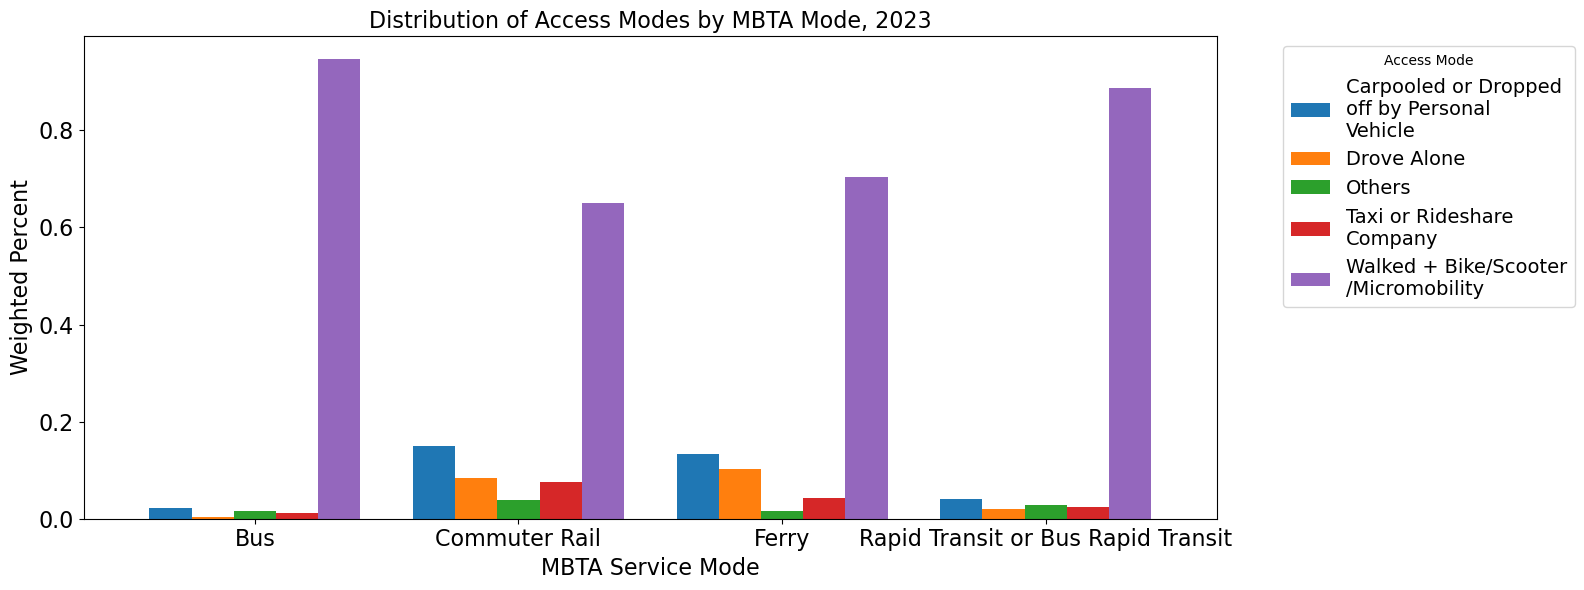

In [53]:
# Plot a grouped bar chart
df_pivot.plot(kind='bar', figsize=(16, 6), width=0.8)

wrapped_labels = [
    '\n'.join(textwrap.wrap(label, width=21))  # Adjust the width as needed
    for label in df_pivot.columns
]

# Adding labels and title
plt.xlabel('MBTA Service Mode', fontsize=16)
plt.ylabel('Weighted Percent', fontsize=16)
plt.title('Distribution of Access Modes by MBTA Mode, 2023', fontsize=16)
plt.legend(labels=wrapped_labels, title='Access Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)  # Puts the legend outside the plot
plt.xticks(rotation=0, fontsize=16)  # Keep service_mode labels horizontal for readability
plt.yticks(fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()

In [51]:
# 2017 data
modeDist_noLog = surveyAccessTimeByMode2017.groupby('MBTA Mode').sum().drop('Access Time', axis=1).round()
modeDist_per = modeDist_noLog.div(modeDist_noLog.sum(axis=1), axis=0)
modeDist_per = modeDist_per[['Carpooled', 'Drove alone', 'Dropped off by personal vehicle', 'Dropped off by other vehicle', 'Walked or bicycled']]

combined_row = modeDist_per.loc[['Rail Rapid Transit', 'Silver Line']].mean()
combined_transit = pd.DataFrame([combined_row], index=['Rapid Transit/Bus Rapid Transit'])
# combined_transit
combined_transit.name = 'Rapid Transit or Bus Rapid Transit'
modeDist_per = modeDist_per.drop(['Rail Rapid Transit', 'Silver Line'])
modeDist_per = pd.concat([modeDist_per, combined_transit])

modeDist_per

,Carpooled,Drove alone,Dropped off by personal vehicle,Dropped off by other vehicle,Walked or bicycled
Bus,0.000856,0.011170,0.009676,0.015343,0.962956
Commuter Rail,0.023066,0.315295,0.096413,0.037415,0.527810
Ferry,0.035794,0.398210,0.031879,0.018736,0.515380
Rapid Transit/Bus Rapid Transit,0.006097,0.028621,0.016022,0.030406,0.918853


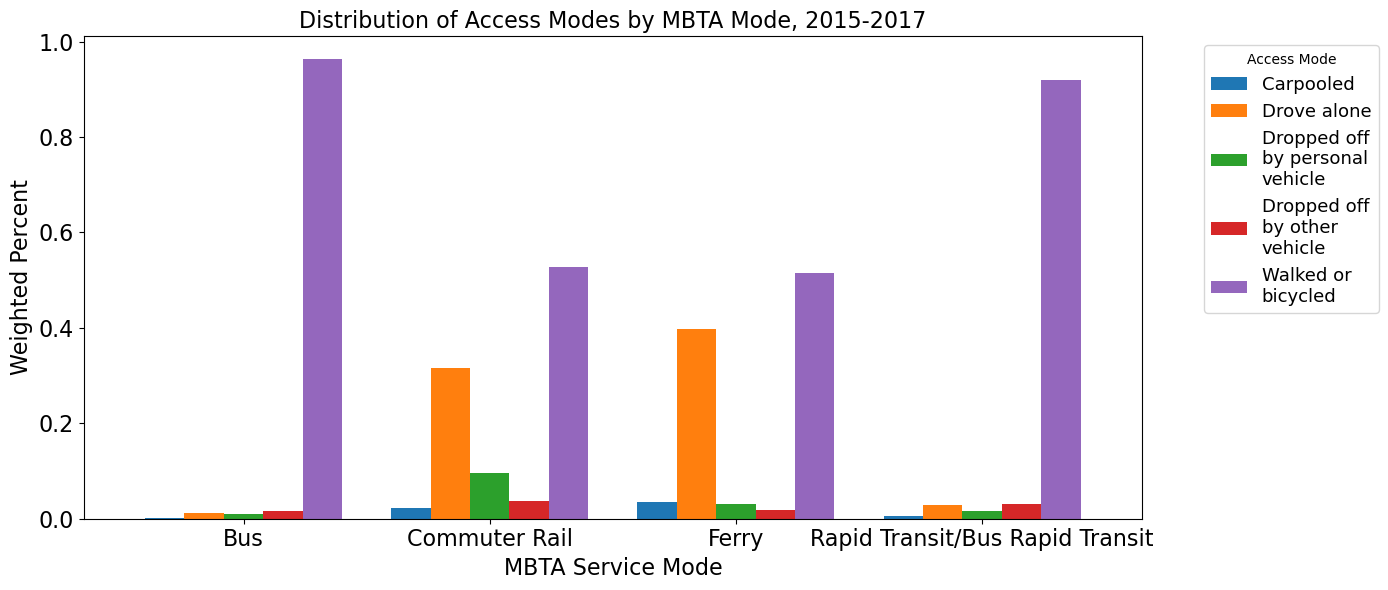

In [56]:
# Plot a grouped bar chart
modeDist_per.plot(kind='bar', figsize=(14, 6), width=0.8)

wrapped_labels = [
    '\n'.join(textwrap.wrap(label, width=12))  # Adjust the width as needed
    for label in modeDist_per.columns
]

# Adding labels and title
plt.xlabel('MBTA Service Mode', fontsize=16)
plt.ylabel('Weighted Percent', fontsize=16)
plt.title('Distribution of Access Modes by MBTA Mode, 2015-2017', fontsize=16)
plt.legend(labels=wrapped_labels, title='Access Mode', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13)  # Puts the legend outside the plot
plt.xticks(rotation=0, fontsize=16)  # Keep service_mode labels horizontal for readability
plt.yticks(fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()